In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv(r'C:\Users\Aditya Kumar\OneDrive\Desktop\project\Ticket price prediction\Support_tickets.csv')
df=df.dropna(subset=['customer_sentiment'])
target_col='downtime_min'
important_col=['customers_affected','error_rate_pct','past_90d_incidents','security_incident_flag',
               'data_loss_flag','payment_impact_flag','product_area_cat','customer_tier_cat','has_runbook']

In [18]:
print('count the values inside the target_col')
count=df[target_col].value_counts()
print(count)
count_zeros=(df[target_col]==0).sum()
print(count_zeros)

count the values inside the target_col
downtime_min
0      24701
6        865
11       836
9        832
10       830
       ...  
137        1
136        1
112        1
147        1
130        1
Name: count, Length: 145, dtype: int64
24701


In [20]:
x=df[important_col].dropna()
y=df[target_col].dropna()
y_log=np.log1p(y)


In [22]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import KFold,train_test_split
from sklearn.svm import SVR                   
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor           
from lightgbm import LGBMRegressor  

In [25]:
X_train,X_test,y_train,y_test=train_test_split(x,y_log,test_size=0.2,random_state=42)
model={
    'SVR':SVR(),
    'decision_tree':DecisionTreeRegressor(random_state=42),
    'random_forest':RandomForestRegressor(random_state=42),
    'xgb':XGBRegressor(n_jobs=-1,random_state=42),
    'lgbm':LGBMRegressor(n_jobs=-1,random_state=42)
}

result=[]
for name,models in model.items():
    models.fit(X_train,y_train)
    y_pred=models.predict(X_test)

    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    result.append({
        'Model':name,
        'r_2':r2,
        'mae':mae,
        'mse':mse,
        'rmse':rmse
    })

result_df=pd.DataFrame(result)
print(result_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 541
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 1.411056
           Model       r_2       mae       mse      rmse
0            SVR -0.712020  1.439042  4.102652  2.025500
1  decision_tree -0.962731  1.643969  4.703452  2.168744
2  random_forest -0.109987  1.474413  2.659953  1.630936
3            xgb -0.041031  1.462256  2.494706  1.579464
4           lgbm  0.002199  1.453155  2.391111  1.546322


In [28]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

tweedie_model = LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.5, 
    n_jobs=-1,
    random_state=42
)

tweedie_model.fit(X_train, y_train)
y_pred = tweedie_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Tweedie LGBM - R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 541
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 2.399322
Tweedie LGBM - R2: 0.0465, MAE: 12.5737, RMSE: 17.3413


<Figure size 1000x600 with 0 Axes>

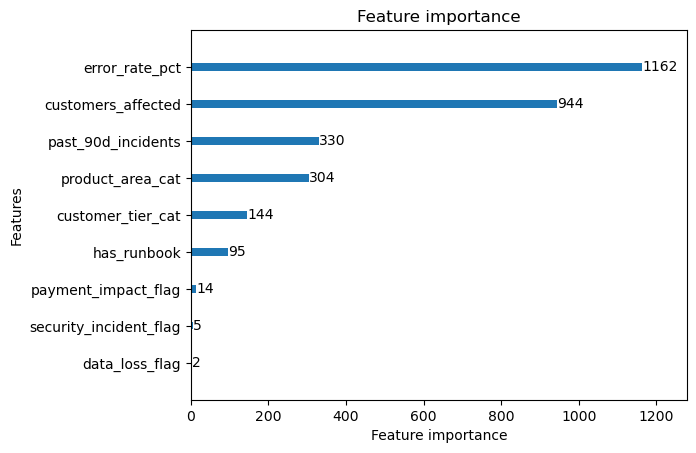

In [32]:
import lightgbm as lgb
plt.figure(figsize=(10,6))
lgb.plot_importance(tweedie_model, max_num_features=10)
plt.grid(False)
plt.show()